# **Finite Difference Method**

Misalkan kita memiliki fungsi $f(x)$. Aproksimasi turunan pertama secara numerik di $x_0$ adalah

$$ f'(x_0) = \frac{f(x_1) - f(x_{-1})}{2h} $$

dengan $x_i = x_0 + i \times h$

Aproksimasi turunan kedua secara numerik di $x_0$ adalah

$$ f''(x_0) = \frac{f'(x_1) - f'(x_{-1})}{2h} = \frac{\frac{f(x_2) - f(x_0)}{2h} - \frac{f(x_0) - f(x_{-2})}{2h}}{2h} = \frac{f(x_2) - 2f(x_0) + f(x_{-2})}{(2h)^2} $$

Karena kita dapat memilih sembarangan $h$ dan kita atur $2h$ menjadi $h$, diperoleh

$$ f''(x_0) = \frac{f(x_1) - 2f(x_0) + f(x_{-1})}{h^2} $$

Sekarang, lihat pada persamaan differensial

$$ y'(x) = F(y,x) $$

Dengan menggunakan turunan pertama diperoleh approksimasi persamaan differensial di atas sebagai

$$ \frac{y(x_1) - y(x_{-1})}{2h} = F(y(x_0), x_0) $$

$$ y(x_1) = y(x_{-1}) + 2hF(y(x_0), x_0) $$

atau set $2h$ menjadi $h$,

$$ y(x_1) = y(x_0) + hF(y(x_{1/2}), x_{1/2}) $$

Model yang ingin diselesaikan:

$$ N'(t) = rN(t) $$

dengan $r$ adalah sebuah koefisien dan $N$ adalah jumlah populasi saat $t$.

Terjemahan model ke dalam metode finite difference:

$$ N_1 = N_0 + hrN_{1/2} $$

## Kasus 1

Mari kita lihat kasus dengan $r$ adalah sebuah konstanta.

Error = 0.37571022369411644


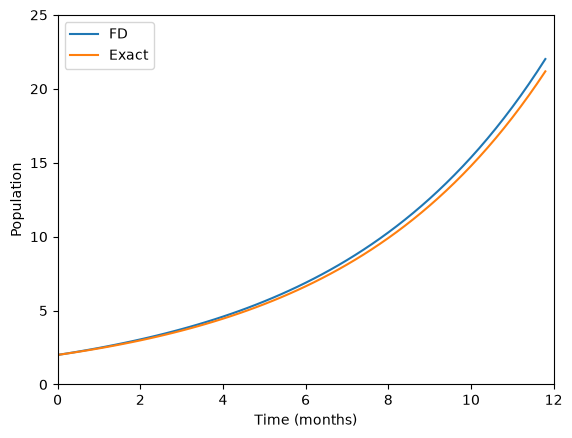

In [8]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.2                 # konstanta
h = 0.2                 # timestep
t = np.arange(0, 12, h) # waktu

N0 = 2                  # Nilai awal
Nh = N0 + N0 * h/2      # beda maju

# Daftar N dan N_1/2
N = [N0]
Nhalf = [Nh]

for i in range(len(t)-1):
    N.append(N[i] + h*r*Nhalf[i])
    Nhalf.append(Nhalf[i] + h*r*N[i+1])

Nexact = N0 * np.exp(r*t)

# Perhitungan error
error = np.sqrt(np.mean(np.square(Nexact - N)))
print(f"Error = {error}")

# Plot Visualisasi
plt.plot(t, N, label='FD')
plt.plot(t, Nexact, label='Exact')
plt.legend()
plt.xlim([0, 12])
plt.ylim([0, 25])
plt.xlabel('Time (months)')
plt.ylabel('Population')
plt.show()

Dalam kode di atas, kita bandingkan metode finite difference dengan solusi eksak. Lihat persamaan differensialnya:

$$ \frac{dN}{dt} = rN $$

Susun ulang persamaan

$$ \frac{dN}{N} = rdt $$

Integralkan kedua ruas persamaan

$$ \ln{N} - \ln{N_0} = rt $$

Kita dapatkan

$$ N = N_0 e^{rt} $$

Bagaimana kita tahu hasil metode finite difference akurat? Kita kuantisasi dengan menggunakan rumus

$$ \text{RMSE} = \sqrt{ \frac{\sum_i^n{(N-N_{exact})^2}}{n}} $$

## Kasus 2

Sekarang lihat untuk kasus model dengan $r$ berubah bergantung pada nilai $N$

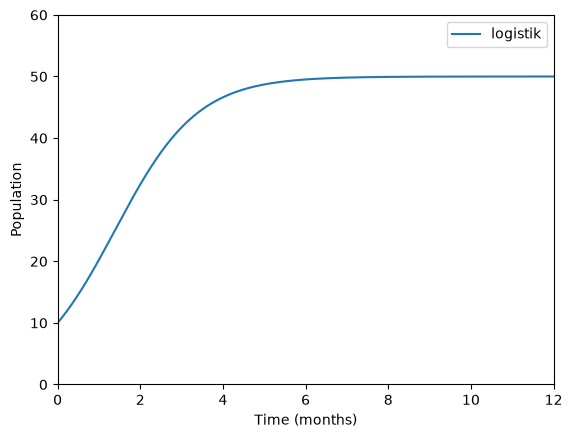

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h  = 0.01               # Langka waktu
r0 = 1                  # Laju pertumbuhan
M  = 50                 # Batas maksimum populasi

t = np.arange(0,12,h)   # Array waktu (setahun)

N0 = 10
Nh = N0 + r0 * (1 - N0/M) * N0 * h/2

N = [N0]
Nhalf = [Nh]

for i in range(len(t)-1):
    N.append(N[i] + h*r0*(1-N[i]/M) * Nhalf[i])
    Nhalf.append(Nhalf[i] + h*r0*(1-Nhalf[i]/M) * N[i+1])

plt.plot(t,N, label='logistik')
plt.xlim([0,12])
plt.ylim([0,60])
plt.legend()
plt.xlabel('Time (months)')
plt.ylabel('Population')
plt.show()